In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
!pip install plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 324.7 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.9 MB 324.7 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.9 MB 324.7 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.9 MB 324.7 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.9 MB 324.7 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.9 MB 324.7 kB/s eta 0:00:29
   --- ------------------------------------ 0.8/9.9 MB 258.6 kB/s eta 0:00:36
   --- ---------------------------------

In [3]:
plt.style.use('seaborn-v0_8')

sns.set_palette('husl')

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
df = pd.read_csv("C:/Users/LENOVO/Downloads/funnel_analysis_data.csv")

df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


In [5]:
print(df.shape)

(21663, 10)


In [6]:
print(df.columns)

Index(['User_ID', 'Session_ID', 'Event', 'Timestamp', 'Device', 'Region',
       'Channel', 'Product_Category', 'Revenue', 'Bounce_Flag'],
      dtype='object')


In [7]:
print(df.dtypes)

User_ID              object
Session_ID           object
Event                object
Timestamp            object
Device               object
Region               object
Channel              object
Product_Category     object
Revenue             float64
Bounce_Flag          object
dtype: object


In [8]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [9]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates}")

df = df.drop_duplicates()



Duplicate Records: 0


In [10]:
print("\nMissing Values")
print(df.isnull().sum())





Missing Values
User_ID             0
Session_ID          0
Event               0
Timestamp           0
Device              0
Region              0
Channel             0
Product_Category    0
Revenue             0
Bounce_Flag         0
dtype: int64


In [11]:
df['Revenue'] = df['Revenue'].fillna(0)
df['Bounce_Flag'] = df['Bounce_Flag'].fillna("No")

In [12]:
df['Date'] = df['Timestamp'].dt.date

df['Month'] = df['Timestamp'].dt.month_name()

df['Day_Name'] = df['Timestamp'].dt.day_name()

df['Hour'] = df['Timestamp'].dt.hour

df['Week_Number'] = df['Timestamp'].dt.isocalendar().week

df['Event_Order'] = df.groupby('Session_ID').cumcount() + 1

In [13]:
print(f"Total Users: {df['User_ID'].nunique():,}")

print(f"Total Sessions: {df['Session_ID'].nunique():,}")

print(f"Total Events: {len(df):,}")

print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")


Total Users: 10,000
Total Sessions: 10,000
Total Events: 21,663
Date Range: 2025-10-01 to 2025-10-31


In [14]:
funnel_stages = [

    'Browse',
    'Add to Cart',
    'Checkout',
    'Purchase'

]

In [15]:
session_summary = df.groupby('Session_ID').agg({

    'User_ID': 'first',

    'Timestamp': ['min', 'max'],

    'Event': lambda x: list(x),

    'Device': 'first',

    'Region': 'first',

    'Channel': 'first',

    'Product_Category': 'first',

    'Revenue': 'sum',

    'Bounce_Flag': 'first'

}).reset_index()

In [16]:
session_summary.columns = [

    'Session_ID',
    'User_ID',
    'Session_Start',
    'Session_End',
    'Event_List',
    'Device',
    'Region',
    'Channel',
    'Product_Category',
    'Revenue',
    'Bounce_Flag'

]

In [17]:
session_summary['Session_Duration_Min'] = (

    session_summary['Session_End'] -
    session_summary['Session_Start']

).dt.total_seconds() / 60

In [18]:
def get_max_stage(events):

    stage_order = {

        stage: i for i, stage in enumerate(funnel_stages)

    }

    max_stage = 0

    for event in events:

        if event in stage_order:

            if stage_order[event] > max_stage:

                max_stage = stage_order[event]

    return funnel_stages[max_stage]

In [19]:
session_summary['Max_Funnel_Stage'] = session_summary[
    'Event_List'
].apply(get_max_stage)



In [20]:
funnel_metrics = []

for i, stage in enumerate(funnel_stages):

    if i == 0:

        sessions = len(session_summary)

    else:

        sessions = len(

            session_summary[
                session_summary['Max_Funnel_Stage'].isin(
                    funnel_stages[i:]
                )
            ]

        )

    funnel_metrics.append({

        'Stage': stage,

        'Sessions': sessions

    })


funnel_df = pd.DataFrame(funnel_metrics)

In [21]:
funnel_df['Conversion_Rate'] = (

    funnel_df['Sessions'] /
    funnel_df['Sessions'].iloc[0]

) * 100


In [22]:

funnel_df['Drop_Off_Rate'] = (

    1 -
    (
        funnel_df['Sessions'] /
        funnel_df['Sessions'].shift(1)
    )

) * 100


funnel_df.loc[0, 'Drop_Off_Rate'] = 0

funnel_df = funnel_df.round(2)


print("\n========== FUNNEL METRICS ==========")

display(funnel_df)


========== FUNNEL METRICS ==========


,Stage,Sessions,Conversion_Rate,Drop_Off_Rate
0,Browse,10000,100.00,0.00
1,Add to Cart,7059,70.59,29.41
2,Checkout,3524,35.24,50.08
3,Purchase,1080,10.80,69.35


In [23]:
total_sessions = len(session_summary)

total_users = session_summary['User_ID'].nunique()

total_revenue = session_summary['Revenue'].sum()

total_orders = len(

    session_summary[
        session_summary['Max_Funnel_Stage'] == 'Purchase'
    ]

)

overall_conversion_rate = (

    total_orders / total_sessions

) * 100

average_order_value = (

    total_revenue / total_orders

)


bounce_rate = (

    len(
        session_summary[
            session_summary['Bounce_Flag'] == 'Yes'
        ]
    ) / total_sessions

) * 100


print("\n========== KPI METRICS ==========")

print(f"Total Users: {total_users:,}")

print(f"Total Sessions: {total_sessions:,}")

print(f"Total Orders: {total_orders:,}")

print(f"Total Revenue: ${total_revenue:,.2f}")

print(f"Overall Conversion Rate: {overall_conversion_rate:.2f}%")

print(f"Average Order Value: ${average_order_value:.2f}")

print(f"Bounce Rate: {bounce_rate:.2f}%")




========== KPI METRICS ==========
Total Users: 10,000
Total Sessions: 10,000
Total Orders: 1,080
Total Revenue: $1,176,405.78
Overall Conversion Rate: 10.80%
Average Order Value: $1089.26
Bounce Rate: 89.20%


In [24]:
fig = make_subplots(

    rows=2,
    cols=2,

    subplot_titles=(

        'Funnel Sessions',
        'Drop-Off Rates',
        'Revenue by Funnel Stage',
        'Average Session Duration'

    )

)

In [25]:
fig.add_trace(

    go.Bar(

        x=funnel_df['Stage'],

        y=funnel_df['Sessions'],

        text=funnel_df['Sessions'],

        textposition='auto',

        name='Sessions'

    ),

    row=1,
    col=1

)

In [26]:
fig.add_trace(

    go.Scatter(

        x=funnel_df['Stage'],

        y=funnel_df['Drop_Off_Rate'],

        mode='lines+markers+text',

        text=funnel_df['Drop_Off_Rate'],

        textposition='top center',

        name='Drop-Off %'

    ),

    row=1,
    col=2

)



In [27]:
revenue_stage = session_summary.groupby(
    'Max_Funnel_Stage'
)['Revenue'].sum().reset_index()


fig.add_trace(

    go.Bar(

        x=revenue_stage['Max_Funnel_Stage'],

        y=revenue_stage['Revenue'],

        text=revenue_stage['Revenue'].round(2),

        textposition='auto',

        name='Revenue'

    ),

    row=2,
    col=1

)

In [28]:
duration_stage = session_summary.groupby(
    'Max_Funnel_Stage'
)['Session_Duration_Min'].mean().reset_index()


fig.add_trace(

    go.Bar(

        x=duration_stage['Max_Funnel_Stage'],

        y=duration_stage['Session_Duration_Min'],

        text=duration_stage[
            'Session_Duration_Min'
        ].round(2),

        textposition='auto',

        name='Duration'

    ),

    row=2,
    col=2

)


fig.update_layout(

    height=800,

    width=1200,

    title='Advanced Funnel Analysis Dashboard',

    showlegend=False

)

fig.show()
duration_stage = session_summary.groupby(
    'Max_Funnel_Stage'
)['Session_Duration_Min'].mean().reset_index()


fig.add_trace(

    go.Bar(

        x=duration_stage['Max_Funnel_Stage'],

        y=duration_stage['Session_Duration_Min'],

        text=duration_stage[
            'Session_Duration_Min'
        ].round(2),

        textposition='auto',

        name='Duration'

    ),

    row=2,
    col=2

)


fig.update_layout(

    height=800,

    width=1200,

    title='Advanced Funnel Analysis Dashboard',

    showlegend=False

)

fig.show()


In [29]:
fig2 = go.Figure(

    go.Funnel(

        y=funnel_df['Stage'],

        x=funnel_df['Sessions'],

        textinfo='value+percent initial'

    )

)

fig2.update_layout(

    title='Customer Funnel Journey'

)

fig2.show()



In [30]:
channel_analysis = session_summary.groupby('Channel').agg({

    'Session_ID': 'count',

    'Revenue': 'sum',

    'Session_Duration_Min': 'mean',

    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()

}).rename(columns={

    'Session_ID': 'Total_Sessions',

    'Max_Funnel_Stage': 'Purchases'

})


channel_analysis['Conversion_Rate'] = (

    channel_analysis['Purchases'] /
    channel_analysis['Total_Sessions']

) * 100


channel_analysis['AOV'] = (

    channel_analysis['Revenue'] /
    channel_analysis['Purchases']

).round(2)


print("\n========== CHANNEL ANALYSIS ==========")

display(channel_analysis)




========== CHANNEL ANALYSIS ==========


,Total_Sessions,Revenue,Session_Duration_Min,Purchases,Conversion_Rate,AOV
Channel,,,,,,
Email,2489,276116.54,4.020490,254,10.204902,1087.07
Google Ads,2560,312769.26,4.034766,282,11.015625,1109.11
Organic,2511,307448.35,4.172840,281,11.190761,1094.12
Social Media,2440,280071.63,4.100820,263,10.778689,1064.91


In [31]:
device_analysis = session_summary.groupby('Device').agg({

    'Session_ID': 'count',

    'Revenue': 'sum',

    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()

}).rename(columns={

    'Session_ID': 'Total_Sessions',

    'Max_Funnel_Stage': 'Purchases'

})


device_analysis['Conversion_Rate'] = (

    device_analysis['Purchases'] /
    device_analysis['Total_Sessions']

) * 100


print("\n========== DEVICE ANALYSIS ==========")

display(device_analysis)




========== DEVICE ANALYSIS ==========


,Total_Sessions,Revenue,Purchases,Conversion_Rate
Device,,,,
Desktop,3331,399395.43,372,11.167817
Mobile,3345,405451.84,363,10.852018
Tablet,3324,371558.51,345,10.379061


In [32]:
region_analysis = session_summary.groupby('Region').agg({

    'Session_ID': 'count',

    'Revenue': 'sum',

    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()

}).rename(columns={

    'Session_ID': 'Total_Sessions',

    'Max_Funnel_Stage': 'Purchases'

})


region_analysis['Conversion_Rate'] = (

    region_analysis['Purchases'] /
    region_analysis['Total_Sessions']

) * 100


print("\n========== REGION ANALYSIS ==========")

display(region_analysis)



========== REGION ANALYSIS ==========


,Total_Sessions,Revenue,Purchases,Conversion_Rate
Region,,,,
East,2514,301767.14,280,11.137629
North,2504,288027.95,261,10.423323
South,2506,311018.57,282,11.252993
West,2476,275592.12,257,10.379645


In [33]:
category_analysis = session_summary.groupby(
    'Product_Category'
).agg({

    'Session_ID': 'count',

    'Revenue': 'sum',

    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()

}).rename(columns={

    'Session_ID': 'Total_Sessions',

    'Max_Funnel_Stage': 'Purchases'

})


category_analysis['Conversion_Rate'] = (

    category_analysis['Purchases'] /
    category_analysis['Total_Sessions']

) * 100


print("\n========== PRODUCT CATEGORY ANALYSIS ==========")

display(category_analysis)





========== PRODUCT CATEGORY ANALYSIS ==========


,Total_Sessions,Revenue,Purchases,Conversion_Rate
Product_Category,,,,
Beauty,1978,241834.97,226,11.425683
Electronics,2046,226451.63,208,10.166178
Fashion,2035,237261.50,220,10.810811
Home,1941,232534.83,211,10.870685
Sports,2000,238322.85,215,10.750000


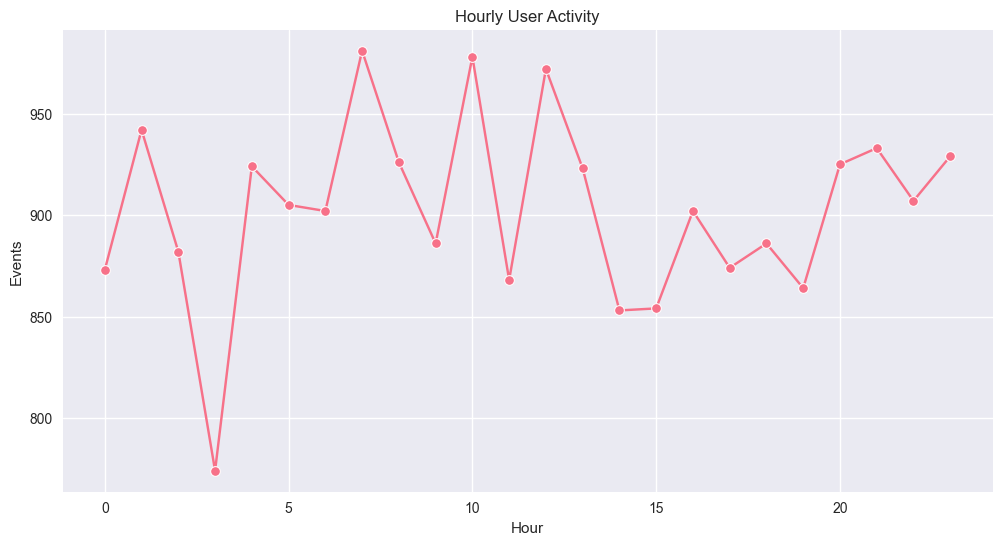

In [34]:
hourly_analysis = df.groupby('Hour').agg({

    'Session_ID': 'count',

    'Revenue': 'sum'

}).rename(columns={

    'Session_ID': 'Total_Events'

})


plt.figure(figsize=(12, 6))

sns.lineplot(

    x=hourly_analysis.index,

    y=hourly_analysis['Total_Events'],

    marker='o'

)

plt.title("Hourly User Activity")

plt.xlabel("Hour")

plt.ylabel("Events")

plt.show()



In [35]:
day_analysis = df.groupby('Day_Name').agg({

    'Revenue': 'sum',

    'Session_ID': 'count'

}).rename(columns={

    'Session_ID': 'Total_Events'

})


print("\n========== DAY ANALYSIS ==========")

display(day_analysis)



========== DAY ANALYSIS ==========


,Revenue,Total_Events
Day_Name,,
Friday,181745.46,3406
Monday,169958.42,2900
Saturday,167030.82,3000
Sunday,167130.83,2982
Thursday,203088.10,3578
Tuesday,142762.45,2876
Wednesday,144689.70,2921


Visualization Saved Successfully


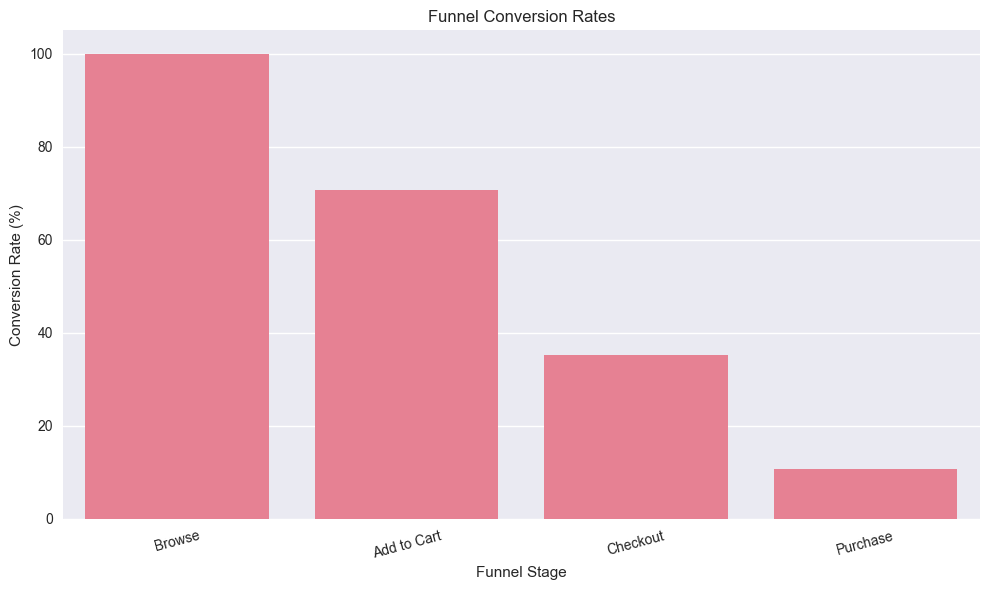

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(

    data=funnel_df,

    x='Stage',

    y='Conversion_Rate'

)

plt.title("Funnel Conversion Rates")

plt.xlabel("Funnel Stage")

plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(

    'funnel_conversion_rates.png',

    dpi=300,

    bbox_inches='tight'

)

print("Visualization Saved Successfully")

In [37]:
report_data = {

    'Funnel_Metrics': funnel_df,

    'Session_Summary': session_summary,

    'Channel_Analysis': channel_analysis,

    'Device_Analysis': device_analysis,

    'Region_Analysis': region_analysis,

    'Category_Analysis': category_analysis,

    'Hourly_Analysis': hourly_analysis,

    'Day_Analysis': day_analysis

}


with pd.ExcelWriter('advanced_funnel_analysis_report.xlsx') as writer:

    for sheet_name, data in report_data.items():

        data.to_excel(

            writer,

            sheet_name=sheet_name,

            index=True

        )


print("\n========== ANALYSIS COMPLETED ==========")

print("Excel Report Exported Successfully")

print("File Name: advanced_funnel_analysis_report.xlsx")




========== ANALYSIS COMPLETED ==========
Excel Report Exported Successfully
File Name: advanced_funnel_analysis_report.xlsx
